In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\Export1.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17553 entries, 0 to 17552
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  17553 non-null  str  
 1   Message  17553 non-null  str  
 2   Status   17553 non-null  str  
dtypes: str(3)
memory usage: 411.5 KB


In [36]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252521    9083
0x252513    5346
0x252501    1465
0x252511    1417
0x252514     242
Name: count, dtype: int64

In [37]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17553 entries, 0 to 17552
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  17553 non-null  str  
 1   Message  17553 non-null  str  
 2   Status   17553 non-null  str  
 3   Headers  17553 non-null  str  
dtypes: str(4)
memory usage: 548.7 KB


In [38]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
odometer=[]
#x_axis_odometer=[]
speed=[]
#x_axis_speed=[]
date_odometer=[]
date_speed=[]
raw_odometer=[]
raw_speed=[]
unit_odometer=pd.DataFrame()
unit_speed=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date_odometer.append(unit_aux.iloc[i,2][106:118])
    raw_odometer.append(unit_aux.iloc[i,2])   

unit_odometer['Odometer in meters']=odometer
unit_odometer['Date']=date_odometer
unit_odometer['Raw data']=raw_odometer

for i in range(0,unit_aux.shape[0]):
    try:
        speed.append(int(unit_aux.iloc[i,2][142:145]))  
        date_speed.append(unit_aux.iloc[i,2][106:118])
        raw_speed.append(unit_aux.iloc[i,2])        
    except:
        pass

unit_speed['Speed']=speed
unit_speed['Date']=date_speed
unit_speed['Raw data']=raw_speed

unit_odometer_ordered=unit_odometer.sort_values('Date',ascending=True)
unit_speed_ordered=unit_speed.sort_values('Date',ascending=True)

unit_odometer_ordered.info()
unit_speed_ordered.info()

<class 'pandas.DataFrame'>
Index: 5588 entries, 0 to 5345
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Odometer in meters  5588 non-null   int64
 1   Date                5588 non-null   str  
 2   Raw data            5588 non-null   str  
dtypes: int64(1), str(2)
memory usage: 174.6 KB
<class 'pandas.DataFrame'>
Index: 4917 entries, 0 to 4674
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Speed     4917 non-null   int64
 1   Date      4917 non-null   str  
 2   Raw data  4917 non-null   str  
dtypes: int64(1), str(2)
memory usage: 153.7 KB


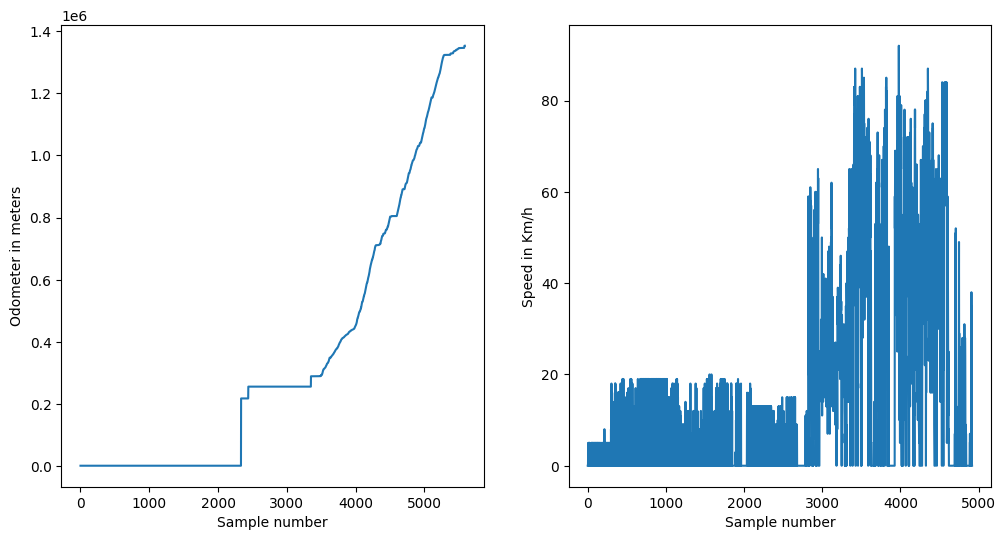

In [39]:
x_axis_odometer=[]
y_axis_odometer=[]
x_axis_speed=[]
y_axis_speed=[]

fig, ax = plt.subplots(1,2, figsize=(12, 6))

for i in range(0,unit_odometer_ordered.shape[0]):
    x_axis_odometer.append(i)
    y_axis_odometer.append(unit_odometer_ordered.iloc[i,0])

for i in range(0,unit_speed_ordered.shape[0]):
    x_axis_speed.append(i)
    y_axis_speed.append(unit_speed_ordered.iloc[i,0])

ax[0].set_xlabel('Sample number')
ax[0].set_ylabel('Odometer in meters')
ax[1].set_xlabel('Sample number')
ax[1].set_ylabel('Speed in Km/h')
ax[0].plot(x_axis_odometer,y_axis_odometer)
ax[1].plot(x_axis_speed,y_axis_speed)